### Objective

#### Imports

In [53]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.feature_selection import RFE, SelectFromModel, SelectKBest, mutual_info_classif, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from xgboost import XGBClassifier


from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score, auc, average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve
)


#### Load preprocessed data

In [54]:
#Load the dataset
project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data
from src.preprocessing import das28_change

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_cleaned=pd.read_pickle('data_cleaned.pkl')

#### Initial checks of the modeling dataset

In [3]:
df_cleaned.shape

(393, 55)

In [4]:
# Examine visit intervals and timeframes
print("Visit intervals between consecutive visits:")
df_sorted = df_cleaned.sort_values(['patient_id', 'visit_date'])
df_sorted['days_to_next_visit'] = df_sorted.groupby('patient_id')['visit_date'].diff().dt.days

print(f"Mean days between visits: {df_sorted['days_to_next_visit'].mean():.1f}")
print(f"Median days between visits: {df_sorted['days_to_next_visit'].median():.1f}")
print(f"Min: {df_sorted['days_to_next_visit'].min():.0f}, Max: {df_sorted['days_to_next_visit'].max():.0f}")
print(f"\nDistribution of days to next visit:")
print(df_sorted['days_to_next_visit'].describe())


Visit intervals between consecutive visits:
Mean days between visits: 234.3
Median days between visits: 181.0
Min: 14, Max: 1293

Distribution of days to next visit:
count     287.000000
mean      234.344948
std       191.733962
min        14.000000
25%       105.000000
50%       181.000000
75%       296.500000
max      1293.000000
Name: days_to_next_visit, dtype: float64


In [5]:
# Stratify by visit interval
print("\nBreakdown by visit interval:")
print(f"Visits <6 months (180 days): {(df_sorted['days_to_next_visit'] < 180).sum()} ({(df_sorted['days_to_next_visit'] < 180).sum()/len(df_sorted)*100:.1f}%)")
print(f"Visits 6-12 months (180-365 days): {((df_sorted['days_to_next_visit'] >= 180) & (df_sorted['days_to_next_visit'] < 365)).sum()} ({((df_sorted['days_to_next_visit'] >= 180) & (df_sorted['days_to_next_visit'] < 365)).sum()/len(df_sorted)*100:.1f}%)")
print(f"Visits >12 months: {(df_sorted['days_to_next_visit'] >= 365).sum()} ({(df_sorted['days_to_next_visit'] >= 365).sum()/len(df_sorted)*100:.1f}%)")

# Check flare rates by interval
print("\nFlare rates by visit interval:")
df_sorted['visit_interval'] = pd.cut(df_sorted['days_to_next_visit'], 
                                       bins=[0, 180, 365, 2000], 
                                       labels=['<6mo', '6-12mo', '>12mo'])
print(df_sorted.groupby('visit_interval')['flare_next_visit'].agg(['count', 'sum', 'mean']))


Breakdown by visit interval:
Visits <6 months (180 days): 142 (36.1%)
Visits 6-12 months (180-365 days): 94 (23.9%)
Visits >12 months: 51 (13.0%)

Flare rates by visit interval:
                count  sum      mean
visit_interval                      
<6mo              142   45  0.316901
6-12mo             94   28  0.297872
>12mo              51   16  0.313725


In [6]:
# Statistical test for flare rate differences by visit interval
# Create contingency table
contingency = pd.crosstab(df_sorted['visit_interval'], df_sorted['flare_next_visit'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square test for independence:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nConclusion: Flare rates {'DO NOT' if p_value > 0.05 else 'DO'} differ significantly across visit intervals (α=0.05)")

Chi-square test for independence:
Chi-square statistic: 0.0995
p-value: 0.9515
Degrees of freedom: 2

Conclusion: Flare rates DO NOT differ significantly across visit intervals (α=0.05)


#### Target Variable Definition
Our prediction target is **"flare occurrence at the patient's next scheduled visit"**, defined as a clinical flare in disease activity occurring between the index visit and the next follow-up visit. 

**Temporal characteristics:**
- Median follow-up interval: 181 days (6 months)
- IQR: 105-296 days
- Range: 14-1293 days

**Flare rates by follow-up interval:**
- <6 months (n=142): 31.7%
- 6-12 months (n=94): 29.8%
- >12 months (n=51): 31.4%

The consistency of flare rates across different visit intervals (p-value suggests no significant difference) validates our modeling approach, as it indicates that disease activity flares occur at relatively stable rates regardless of follow-up timing.


#### Define target, groups, and candidate features

In [59]:
#Define the target variable
target_variable = 'flare_next_visit'

#Drop the columns that are not needed for modeling plus the target variable, after EDA analysis.

drop_columns = [
    target_variable,
    'das28_change',
    'flare_event',
    'visit_date', 
    'source',
    'year_of_diagnosis',
    'crp_normalized',
    'crp_upper_limit',
    'crp',
    'esr',
    'mtx_use',
    'steroid_use',
    'mtx_dose_category',
    'steroid_dose_category',
    'comorbidities',
    'csdmard_name',
    'b_ts_dmard_name', 
    'switch_reason', 
    'treatment_decision',
    'birth_year',
    'das28_bins',
    'visit_type',
    'disease_duration',
    'comorb_renal_urological',
    'comorb_malignancy',
    'age_bins',
    'esr_missing',
    'crp_missing',
    'das28_missing'
    
]

#Define the feature matrix X 
X = df_cleaned.drop(columns = drop_columns, errors='ignore')

#Define the target variable y
y = df_cleaned[target_variable]

#Define the groups for group-aware splitting
groups = df_cleaned['patient_id']

In [8]:
print('x shape: ', X.shape)
print('y shape: ', y.shape)

x shape:  (393, 26)
y shape:  (393,)


In [9]:
X.columns.to_list()

['patient_id',
 'gender',
 'rf_status',
 'anti_ccp_status',
 'das28_score',
 'mtx_dose',
 'steroid_dose',
 'treatment_decision_grouped',
 'days_since_last_visit',
 'age_at_visit',
 'previous_flare',
 'inflammation_flag',
 'comorb_cardiovascular',
 'comorb_metabolic_endocrine',
 'comorb_respiratory',
 'comorb_gastrointestinal_hepatic',
 'comorb_musculoskeletal',
 'comorb_neurologic_psychiatric',
 'comorb_autoimmune_other',
 'comorbidity_count',
 'csdmard_use',
 'b_ts_dmard_use',
 'treatment_count',
 'log_crp_normalized',
 'log_esr',
 'log_disease_duration']

In [62]:
continuous_features = [ 
    'steroid_dose',
    'mtx_dose',
    'age_at_visit',
    'days_since_last_visit',
    'comorbidity_count',
    'treatment_count'
]

binary_features=[
    'gender',
    'rf_status',
    'anti_ccp_status',
    'csdmard_use',
    'b_ts_dmard_use',
    'inflammation_flag',
    'previous_flare',
    'comorb_cardiovascular',
    'comorb_metabolic_endocrine',
    'comorb_respiratory',
    'comorb_gastrointestinal_hepatic',
    'comorb_musculoskeletal',
    'comorb_autoimmune_other',
    'comorb_neurologic_psychiatric'
]

categorical_features = [
    'treatment_decision_grouped'
]

#### Build preprocessing pipeline

In [11]:
group_kfold = GroupKFold(n_splits=5)
stratified_group_kfold = StratifiedGroupKFold(n_splits=5)
for i, (train_index, test_index) in enumerate(group_kfold.split(X, y, groups)):
    print(f"Fold {i}, overlap:", set(groups.iloc[train_index]).intersection(groups.iloc[test_index]))

Fold 0, overlap: set()
Fold 1, overlap: set()
Fold 2, overlap: set()
Fold 3, overlap: set()
Fold 4, overlap: set()


#### Baseline models
We compare all four models together in their baseline phase in order to see differences


Testing Median Imputation Strategy

                          Accuracy      Precision         Recall       F1 Score        ROC AUC Average Precision
Logistic Regression  0.591 ± 0.095  0.414 ± 0.120  0.487 ± 0.148  0.439 ± 0.112  0.583 ± 0.109     0.473 ± 0.120
Random Forest        0.619 ± 0.100  0.443 ± 0.159  0.401 ± 0.107  0.415 ± 0.122  0.637 ± 0.101     0.468 ± 0.096
XGBoost              0.621 ± 0.066  0.425 ± 0.113  0.316 ± 0.062  0.357 ± 0.075  0.546 ± 0.101     0.402 ± 0.078
SVM                  0.631 ± 0.106  0.472 ± 0.139  0.509 ± 0.111  0.483 ± 0.114  0.633 ± 0.080     0.466 ± 0.066

Testing KNN Imputation Strategy

                          Accuracy      Precision         Recall       F1 Score        ROC AUC Average Precision
Logistic Regression  0.590 ± 0.076  0.409 ± 0.098  0.495 ± 0.162  0.438 ± 0.102  0.568 ± 0.112     0.458 ± 0.117
Random Forest        0.624 ± 0.073  0.437 ± 0.127  0.407 ± 0.088  0.419 ± 0.101  0.623 ± 0.085     0.465 ± 0.095
XGBoost              0.61

c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

                          Accuracy      Precision         Recall       F1 Score        ROC AUC Average Precision
Logistic Regression  0.596 ± 0.088  0.414 ± 0.120  0.495 ± 0.170  0.443 ± 0.122  0.577 ± 0.111     0.459 ± 0.109
Random Forest        0.647 ± 0.071  0.465 ± 0.127  0.431 ± 0.113  0.446 ± 0.116  0.642 ± 0.096     0.468 ± 0.102
XGBoost              0.586 ± 0.076  0.369 ± 0.127  0.285 ± 0.054  0.318 ± 0.077  0.580 ± 0.111     0.451 ± 0.104
SVM                  0.623 ± 0.099  0.463 ± 0.119  0.533 ± 0.121  0.486 ± 0.098  0.630 ± 0.083     0.461 ± 0.071

CROSS-STRATEGY COMPARISON (Mean Metrics)

               Accuracy  Precision  Recall  F1 Score  ROC AUC  Average Precision
Median            0.615      0.439   0.428     0.423    0.600              0.452
KNN               0.612      0.427   0.428     0.419    0.596              0.449
MICE_Bayesian     0.621      0.438   0.434     0.426    0.603              0.455
MICE_RF           0.613      0.428   0.436     0.423    0.607       

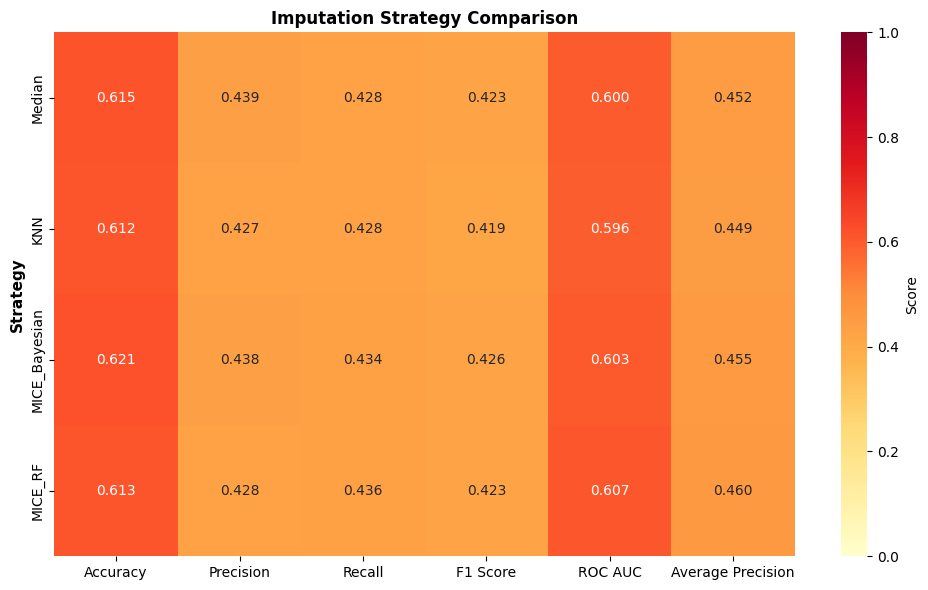

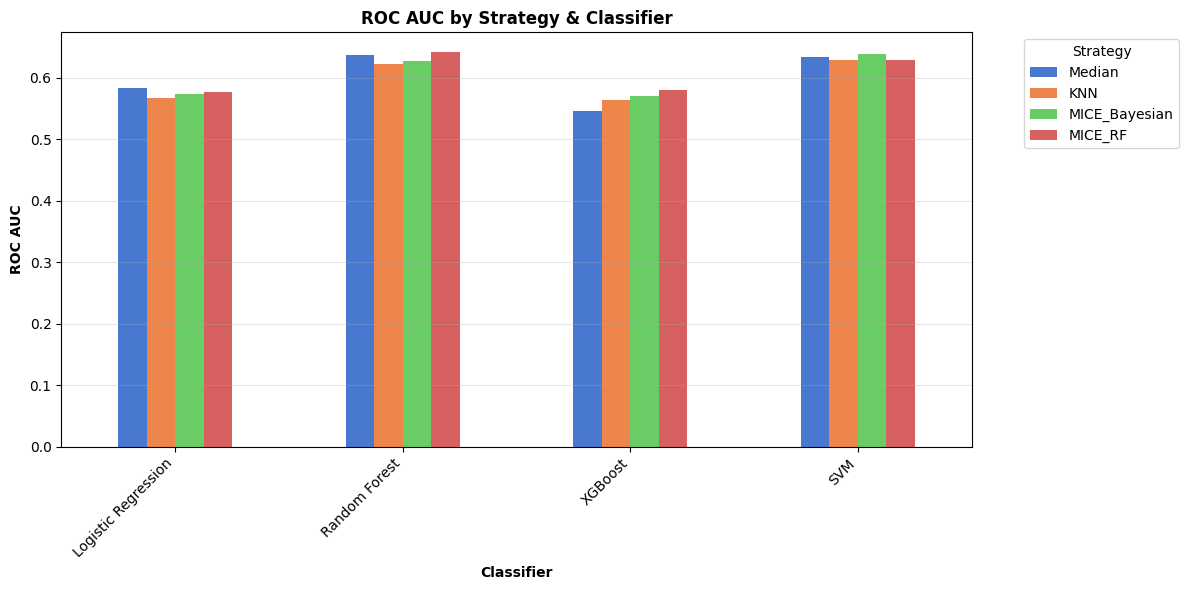

In [16]:
# Define preprocessing pipelines with multiple imputation strategies

features = ['das28_score', 'log_esr', 'log_crp_normalized', 'log_disease_duration']

# Helper function for das28_change recalculation (shared across all strategies)
def recalculate_das28_change(df):
    df = df.copy()
    das28_col = [col for col in df.columns if 'das28_score' in col]
    patient_id_col = [col for col in df.columns if 'patient_id' in col]
    
    if das28_col and patient_id_col:
        das28_col = das28_col[0]
        patient_id_col = patient_id_col[0]
        
        # Recalculate das28_change from the newly imputed das28_score values
        df['das28_change'] = df.groupby(patient_id_col)[das28_col].diff().fillna(0)
        
        # Drop patient_id as it's not needed for the model
        df = df.drop(columns=[patient_id_col])
    
    return df

# Single preprocessor factory function
def create_preprocessor(disease_metrics_imputer_pipeline):

    preprocessor_parent = ColumnTransformer(transformers=[
        ('cont', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), continuous_features),
        
        ('disease_metrics', disease_metrics_imputer_pipeline, features),
        
        ('bin', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ]), binary_features),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ], remainder='passthrough')
    
    preprocessor_parent.set_output(transform="pandas")
    
    return Pipeline(steps=[
        ('preprocessor_parent', preprocessor_parent),
        ('recalc_das28', FunctionTransformer(recalculate_das28_change, validate=False)),
        ('final_scaler', StandardScaler())
    ])

# Define imputation strategy pipelines
imputation_strategies = {
    'Median': create_preprocessor(Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])),
    'KNN': create_preprocessor(Pipeline(steps=[
        ('scaler_before', StandardScaler()),
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler_after', StandardScaler())
    ])),
    'MICE_Bayesian': create_preprocessor(Pipeline(steps=[
        ('scaler_before', StandardScaler()),
        ('imputer', IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10)),
        ('scaler_after', StandardScaler())
    ])),
    'MICE_RF': create_preprocessor(Pipeline(steps=[
        ('scaler_before', StandardScaler()),
        ('imputer', IterativeImputer(estimator=RandomForestRegressor(n_estimators=50, max_depth = 5,
                                                                     random_state=42, n_jobs=-1), random_state=42, max_iter=10)),
        ('scaler_after', StandardScaler())
    ]))
}

# Run baseline classifiers across all imputation strategies
all_results = {}

for strategy_name, preprocessor in imputation_strategies.items():
    print(f"\n{'='*115}\nTesting {strategy_name} Imputation Strategy\n{'='*115}\n")
    
    # Define baseline classifiers for this strategy
    baseline_classifiers = {
        'Logistic Regression': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(max_iter=1000,
                                              class_weight='balanced',
                                              random_state=42))
        ]),
        
        'Random Forest': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(max_depth=5,
                                                  min_samples_split=5,
                                                  min_samples_leaf=2,
                                                  class_weight='balanced',
                                                  random_state=42,
                                                  n_jobs=-1))
        ]),
        
        'XGBoost': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', XGBClassifier(max_depth=5,
                                         scale_pos_weight=1,
                                         random_state=42,
                                         eval_metric='logloss',
                                         n_jobs=-1))
        ]),
        
        'SVM': Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', SVC(class_weight='balanced',
                               probability=True,
                               random_state=42))
        ])
    }
    
    # Run cross-validation
    cv_results = {}
    
    for clf_name, clf_template in baseline_classifiers.items():
        cv_results[clf_name] = {
            'Accuracy': [],
            'Precision': [],
            'Recall': [],
            'F1 Score': [],
            'ROC AUC': [],
            'Average Precision': []
        }
        
        for train_idx, test_idx in stratified_group_kfold.split(X, y, groups):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            clf = clone(clf_template)

            if clf_name == 'XGBoost':
                fold_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
                clf.set_params(classifier__scale_pos_weight=fold_scale_pos_weight)

            clf.fit(X_train, y_train)
            y_pred, y_pred_proba = clf.predict(X_test), clf.predict_proba(X_test)[:, 1]
            
            cv_results[clf_name]['Accuracy'].append(accuracy_score(y_test, y_pred))
            cv_results[clf_name]['Precision'].append(precision_score(y_test, y_pred, zero_division=0))
            cv_results[clf_name]['Recall'].append(recall_score(y_test, y_pred, zero_division=0))
            cv_results[clf_name]['F1 Score'].append(f1_score(y_test, y_pred, zero_division=0))
            cv_results[clf_name]['ROC AUC'].append(roc_auc_score(y_test, y_pred_proba))
            cv_results[clf_name]['Average Precision'].append(average_precision_score(y_test, y_pred_proba))
    
    # Store results by strategy
    all_results[strategy_name] = cv_results
    
    # Display results for this strategy
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Average Precision']
    results_df = pd.DataFrame({clf: {m: f"{np.mean(s):.3f} ± {np.std(s):.3f}" for m, s in cv_results[clf].items()} for clf in cv_results}).T
    print(results_df.to_string())

# Cross-strategy comparison
print(f"\n{'='*115}\nCROSS-STRATEGY COMPARISON (Mean Metrics)\n{'='*115}\n")

comparison_data = {}
for strategy_name in imputation_strategies.keys():
    comparison_data[strategy_name] = {}
    for metric in metric_names:
        strategy_scores = []
        for clf_name in all_results[strategy_name].keys():
            strategy_scores.extend(all_results[strategy_name][clf_name][metric])
        comparison_data[strategy_name][metric] = np.mean(strategy_scores)

comparison_df = pd.DataFrame(comparison_data).T
print(comparison_df.round(3).to_string())

# Visualizations

# Plot 1: Strategy comparison heatmap
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.heatmap(comparison_df, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Score'}, vmin=0, vmax=1, ax=ax1)
ax1.set_title('Imputation Strategy Comparison', fontweight='bold', fontsize=12)
ax1.set_ylabel('Strategy', fontweight='bold', fontsize = 11)
plt.tight_layout()
plt.show()

# Plot 2: ROC AUC comparison across strategies and classifiers
fig2, ax2 = plt.subplots(figsize=(12, 6))
roc_auc_by_strategy_clf = {}
for strategy_name in imputation_strategies.keys():
    roc_auc_by_strategy_clf[strategy_name] = [np.mean(all_results[strategy_name][clf]['ROC AUC'])  for clf in baseline_classifiers.keys()]

roc_auc_df = pd.DataFrame(roc_auc_by_strategy_clf, index=list(baseline_classifiers.keys()))
roc_auc_df.plot(kind='bar', ax=ax2, color=sns.color_palette('muted', len(imputation_strategies)))
ax2.set_title('ROC AUC by Strategy & Classifier', fontweight='bold', fontsize=12)
ax2.set_ylabel('ROC AUC', fontweight='bold')
ax2.set_xlabel('Classifier', fontweight='bold')
ax2.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [60]:
preprocessor = imputation_strategies['MICE_RF']

In [61]:
final_results = {}

#### Logistic Regression
Experiment 1.1
Feature selection method: SelectfromModel  
Solver: saga  
L1 regularization


In [62]:
selector_lr = SelectFromModel(
    estimator=LogisticRegression(
        l1_ratio=1,
        solver='saga',
        C=0.1,
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    )
 )

model_lr_embedded = LogisticRegression(
    solver='saga',
    max_iter=5000,
    random_state=42
)


model_pipeline_lr_embedded = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('selector', selector_lr),
    ('classifier', model_lr_embedded)
 ])


param_grid_lr_embedded = {
    'selector__estimator__C': [0.01, 0.05, 0.1, 1],
    'selector__threshold': ['median', 'mean', '1.25*median', '0.75*median'],
    'classifier__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': ['balanced', None],
 }

grid_lr_embedded = GridSearchCV(
    estimator=model_pipeline_lr_embedded,
    param_grid=param_grid_lr_embedded,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=3
 )

grid_lr_embedded.fit(X, y, groups=groups)

best_lr_embedded = grid_lr_embedded.best_estimator_
y_prob_lr_embedded = cross_val_predict(best_lr_embedded, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_lr_embedded)
roc_auc = roc_auc_score(y, y_prob_lr_embedded)
ap_score = average_precision_score(y, y_prob_lr_embedded)

print("Best params:", grid_lr_embedded.best_params_)
print(f"Best CV score: {grid_lr_embedded.best_score_:.3f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print(f"Maximum Probability: {np.max(y_prob_lr_embedded):.4f}")
print(f"Minimum Probability: {np.min(y_prob_lr_embedded):.4f}")
print(f"Average Probability: {np.mean(y_prob_lr_embedded):.4f}\n")


precisions, recalls, thresholds = precision_recall_curve(y, y_prob_lr_embedded)

# Calculate the F1 score for every single threshold, adding 1e-10 prevents 'divide by zero' errors
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_results['Experiment_1.1_LR_SelectFromModel'] = {
    # Cross-validation scores
    'cv_score': grid_lr_embedded.best_score_, 
    'ap_score': ap_score,              
    'roc_auc': roc_auc,               
    
    # True labels and predictions
    'y_true': y.copy(),                
    'y_prob': y_prob_lr_embedded,               
    
    # ROC curve data
    'roc_fpr': roc_fpr,               
    'roc_tpr': roc_tpr,              
    
    # PR curve data
    'precision': precisions,          
    'recall': recalls,                 
}

Fitting 5 folds for each of 800 candidates, totalling 4000 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

Best params: {'classifier__C': 0.01, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.25, 'selector__estimator__C': 0.05, 'selector__threshold': 'mean'}
Best CV score: 0.528
Average Precision: 0.4809
ROC AUC: 0.6912
Maximum Probability: 0.4514
Minimum Probability: 0.2315
Average Probability: 0.3308

Optimal Threshold: 0.3251



In [66]:
y_pred_lr = (y_prob_lr_embedded >= 0.3251).astype(int)

# Compute and display metrics
print("\n" + "="*60)
print("LOGISTIC REGRESSION - RESULTS")
print("="*60)
print(classification_report(y, y_pred_lr, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_lr):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_lr_embedded):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_lr_embedded):.2f}")
print("="*60)


LOGISTIC REGRESSION - RESULTS
              precision    recall  f1-score   support

           0       0.82      0.57      0.68       263
           1       0.46      0.75      0.57       130

    accuracy                           0.63       393
   macro avg       0.64      0.66      0.62       393
weighted avg       0.70      0.63      0.64       393

accuracy_score: 0.63
average_precision_score: 0.48
ROC AUC: 0.69


#### Experiment 1.2 Logistic Regression
Feature selection method: RFE

In [65]:
selector_lr_rfe= RFE(
    estimator=LogisticRegression(
        l1_ratio=0,
        solver='saga',
        C=0.1,
        class_weight='balanced',
        max_iter=5000,
        random_state=42 
),
    n_features_to_select=4,
    
)

model_lr_rfe = LogisticRegression(
    l1_ratio=0,                     
    solver='saga',
    max_iter=5000,
    random_state=42
)

model_pipeline_lr_rfe = Pipeline(steps=[
    ('preprocessor_rfe', clone(preprocessor)),
    ('selector_lr_rfe', selector_lr_rfe),
    ('classifier_rfe', model_lr_rfe)
])


param_grid_lr = {
    'selector_lr_rfe__estimator__C': [0.01, 0.05, 0.1, 0.5, 1],
    'selector_lr_rfe__n_features_to_select': [3, 5, 8, 10],

    'classifier_rfe__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier_rfe__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'classifier_rfe__class_weight': ['balanced', None],
  
 }

grid_lr_rfe = GridSearchCV(
    estimator=model_pipeline_lr_rfe,
    param_grid=param_grid_lr,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=3
)

grid_lr_rfe.fit(X, y, groups=groups)

best_lr_rfe = grid_lr_rfe.best_estimator_
y_prob_lr_rfe = cross_val_predict(best_lr_rfe, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_lr_rfe)
roc_auc = roc_auc_score(y, y_prob_lr_rfe)
ap_score = average_precision_score(y, y_prob_lr_rfe)

print("Best params:", grid_lr_rfe.best_params_)
print(f"Best CV score: {grid_lr_rfe.best_score_:.3f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print(f"Maximum Probability: {np.max(y_prob_lr_rfe):.4f}")
print(f"Minimum Probability: {np.min(y_prob_lr_rfe):.4f}")
print(f"Average Probability: {np.mean(y_prob_lr_rfe):.4f}\n")


precisions, recalls, thresholds = precision_recall_curve(y, y_prob_lr_rfe)

# Calculate the F1 score for every single threshold, adding 1e-10 prevents 'divide by zero' errors
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_results['Experiment_1.2_LR_RFE'] = {
    # Cross-validation scores
    'cv_score': grid_lr_rfe.best_score_, 
    'ap_score': ap_score,              
    'roc_auc': roc_auc,               
    
    # True labels and predictions
    'y_true': y.copy(),                
    'y_prob': y_prob_lr_rfe,               
    
    # ROC curve data
    'roc_fpr': roc_fpr,               
    'roc_tpr': roc_tpr,              
    
    # PR curve data
    'precision': precisions,          
    'recall': recalls,                 
}

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

Best params: {'classifier_rfe__C': 0.01, 'classifier_rfe__class_weight': 'balanced', 'classifier_rfe__l1_ratio': 0.25, 'selector_lr_rfe__estimator__C': 0.05, 'selector_lr_rfe__n_features_to_select': 3}
Best CV score: 0.540
Average Precision: 0.4834
ROC AUC: 0.6888
Maximum Probability: 0.6398
Minimum Probability: 0.3507
Average Probability: 0.4941

Optimal Threshold: 0.4892



In [70]:
y_pred__lr_rfe = (y_prob_lr_rfe >= 0.4892).astype(int)

# Compute and display metrics
print("\n" + "="*60)
print("LOGISTIC REGRESSION - RFE RESULTS")
print("="*60)
print(classification_report(y, y_pred__lr_rfe, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred__lr_rfe):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_lr_rfe):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_lr_rfe):.2f}")
print("="*60)


LOGISTIC REGRESSION - RFE RESULTS
              precision    recall  f1-score   support

           0       0.81      0.58      0.68       263
           1       0.46      0.72      0.56       130

    accuracy                           0.63       393
   macro avg       0.64      0.65      0.62       393
weighted avg       0.69      0.63      0.64       393

accuracy_score: 0.63
average_precision_score: 0.48
ROC AUC: 0.69


### Experiment 1.3 Logistic Regression
Feature selection method: Mutual information

In [71]:
selector_lr_mi = SelectKBest(mutual_info_classif, k=5)

model_lr_mi = LogisticRegression(
    l1_ratio=0,
    solver='saga',
    max_iter=5000,
    random_state=42
)

model_pipeline_lr_mi = Pipeline(steps=[
    ('preprocessor_mi', clone(preprocessor)),  
    ('selector_lr_mi', selector_lr_mi),
    ('classifier_mi', model_lr_mi)
])

param_grid_lr_mi = {
    'selector_lr_mi__k': [3, 5, 8, 10, 15],
    'classifier_mi__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier_mi__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'classifier_mi__class_weight': ['balanced', None],
}

grid_lr_mi = GridSearchCV(
    estimator=model_pipeline_lr_mi, 
    param_grid=param_grid_lr_mi,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=3
)   

grid_lr_mi.fit(X, y, groups=groups)

best_lr_mi = grid_lr_mi.best_estimator_
y_prob_lr_mi = cross_val_predict(best_lr_mi, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

roc_fpr_mi, roc_tpr_mi, _ = roc_curve(y, y_prob_lr_mi)
roc_auc = roc_auc_score(y, y_prob_lr_mi)
ap_score = average_precision_score(y, y_prob_lr_mi)

print("Best params:", grid_lr_mi.best_params_)
print(f"Best CV score: {grid_lr_mi.best_score_:.3f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print(f"Maximum Probability: {np.max(y_prob_lr_mi):.4f}")
print(f"Minimum Probability: {np.min(y_prob_lr_mi):.4f}")
print(f"Average Probability: {np.mean(y_prob_lr_mi):.4f}\n")


precisions, recalls, thresholds = precision_recall_curve(y, y_prob_lr_mi)

# Calculate the F1 score for every single threshold, adding 1e-10 prevents 'divide by zero' errors
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_results['Experiment_1.3_LR_Mutual_Information'] = {
    # Cross-validation scores
    'cv_score': grid_lr_mi.best_score_, 
    'ap_score': ap_score,              
    'roc_auc': roc_auc,               
    
    # True labels and predictions
    'y_true': y.copy(),                
    'y_prob': y_prob_lr_mi,               
    
    # ROC curve data
    'roc_fpr': roc_fpr_mi,               
    'roc_tpr': roc_tpr_mi,              
    
    # PR curve data
    'precision': precisions,          
    'recall': recalls,                 
}

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

Best params: {'classifier_mi__C': 100, 'classifier_mi__class_weight': None, 'classifier_mi__l1_ratio': 0.5, 'selector_lr_mi__k': 10}
Best CV score: 0.536
Average Precision: 0.3862
ROC AUC: 0.5827
Maximum Probability: 0.8340
Minimum Probability: 0.0414
Average Probability: 0.3221

Optimal Threshold: 0.1748



In [79]:
y_pred_lr_mi = (y_prob_lr_mi >= 0.3).astype(int)

print("\n" + "="*60)
print("LOGISTIC REGRESSION - MI RESULTS")
print("="*60)
print(classification_report(y, y_pred_lr_mi, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_lr_mi):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_lr_mi):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_lr_mi):.2f}")
print("="*60)



LOGISTIC REGRESSION - MI RESULTS
              precision    recall  f1-score   support

           0       0.71      0.56      0.63       263
           1       0.38      0.55      0.45       130

    accuracy                           0.55       393
   macro avg       0.55      0.55      0.54       393
weighted avg       0.60      0.55      0.57       393

accuracy_score: 0.55
average_precision_score: 0.39
ROC AUC: 0.58


#### Random Forest
Experiment 2.1

In [80]:
model_rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('classifier', model_rf)
])

param_grid_rf ={
    'classifier__n_estimators': [ 100,200, 300, 400],
    'classifier__max_depth': [4, 6, 8, 10, None],
    'classifier__min_samples_leaf': [1, 2, 3, 4],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']

}

grid_rf = GridSearchCV(
    estimator=model_pipeline_rf,
    param_grid=param_grid_rf,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X, y, groups=groups)

best_rf = grid_rf.best_estimator_
y_prob_rf = cross_val_predict(best_rf, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_rf)
roc_auc = roc_auc_score(y, y_prob_rf)
ap_score = average_precision_score(y, y_prob_rf)

print("Best params:", grid_rf.best_params_)
print(f"Best CV score: {grid_rf.best_score_:.3f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print(f"Maximum Probability: {np.max(y_prob_rf):.4f}")
print(f"Minimum Probability: {np.min(y_prob_rf):.4f}")
print(f"Average Probability: {np.mean(y_prob_rf):.4f}\n")


precisions, recalls, thresholds = precision_recall_curve(y, y_prob_rf)

# Calculate the F1 score for every single threshold, adding 1e-10 prevents 'divide by zero' errors
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_results['Experiment_2.1_RF'] = {
    # Cross-validation scores
    'cv_score': grid_rf.best_score_, 
    'ap_score': ap_score,              
    'roc_auc': roc_auc,               
    
    # True labels and predictions
    'y_true': y.copy(),                
    'y_prob': y_prob_rf,               
    
    # ROC curve data
    'roc_fpr': roc_fpr,               
    'roc_tpr': roc_tpr,              
    
    # PR curve data
    'precision': precisions,          
    'recall': recalls,                 
}

Fitting 5 folds for each of 640 candidates, totalling 3200 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

Best params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 8, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 200}
Best CV score: 0.492
Average Precision: 0.4292
ROC AUC: 0.6295
Maximum Probability: 0.7467
Minimum Probability: 0.0887
Average Probability: 0.3981

Optimal Threshold: 0.3295



In [89]:
y_pred_rf = (y_prob_rf >= 0.32).astype(int)

print("\n" + "="*60)
print("RANDOM FOREST - RF RESULTS")
print("="*60)
print(classification_report(y, y_pred_rf, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_rf):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_rf):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_rf):.2f}")
print("="*60)


RANDOM FOREST - RF RESULTS
              precision    recall  f1-score   support

           0       0.82      0.35      0.49       263
           1       0.39      0.85      0.54       130

    accuracy                           0.51       393
   macro avg       0.61      0.60      0.51       393
weighted avg       0.68      0.51      0.51       393

accuracy_score: 0.51
average_precision_score: 0.43
ROC AUC: 0.63


### Experiment 2.2
Feature selection method: SelectFromModel


In [90]:
selector_rf = SelectFromModel(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        criterion='gini',
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),
    threshold='median'
)

model_rf_embedded = RandomForestClassifier(
    criterion='gini',
    random_state=42,
    n_jobs=1
)

model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('selector', selector_rf),
    ('classifier', model_rf_embedded)
])

param_grid_rf_embedded = {
    'selector__estimator__n_estimators': [100, 200],
    'selector__threshold': ['median', 'mean', '1.25*median', '0.75*median'],
    'selector__estimator__max_depth': [5, 10],
    
    'classifier__n_estimators': [150, 200, 350],
    'classifier__max_depth': [4, 5, 8, None],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}


grid_rf_embedded = GridSearchCV(
    estimator=model_pipeline_rf,
    param_grid=param_grid_rf_embedded,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=3
)

grid_rf_embedded.fit(X, y, groups=groups)

best_rf_embedded = grid_rf_embedded.best_estimator_
y_prob_rf_embedded = cross_val_predict(best_rf_embedded, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_rf_embedded)
roc_auc = roc_auc_score(y, y_prob_rf_embedded)
ap_score = average_precision_score(y, y_prob_rf_embedded)

print("Best params:", grid_rf_embedded.best_params_)
print(f"Best CV score: {grid_rf_embedded.best_score_:.3f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print(f"Maximum Probability: {np.max(y_prob_rf_embedded):.4f}")
print(f"Minimum Probability: {np.min(y_prob_rf_embedded):.4f}")
print(f"Average Probability: {np.mean(y_prob_rf_embedded):.4f}\n")


precisions, recalls, thresholds = precision_recall_curve(y, y_prob_rf_embedded)

# Calculate the F1 score for every single threshold, adding 1e-10 prevents 'divide by zero' errors
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_results['Experiment_2.2_RF_SelectFromModel'] = {
    # Cross-validation scores
    'cv_score': grid_rf_embedded.best_score_, 
    'ap_score': ap_score,              
    'roc_auc': roc_auc,               
    
    # True labels and predictions
    'y_true': y.copy(),                
    'y_prob': y_prob_rf_embedded,               
    
    # ROC curve data
    'roc_fpr': roc_fpr,               
    'roc_tpr': roc_tpr,              
    
    # PR curve data
    'precision': precisions,          
    'recall': recalls,                 
}

Fitting 5 folds for each of 1536 candidates, totalling 7680 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

Best params: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 150, 'selector__estimator__max_depth': 10, 'selector__estimator__n_estimators': 100, 'selector__threshold': '0.75*median'}
Best CV score: 0.490
Average Precision: 0.4230
ROC AUC: 0.6308
Maximum Probability: 0.7397
Minimum Probability: 0.0827
Average Probability: 0.4147

Optimal Threshold: 0.2643



In [93]:
y_pred_rf_embedded = (y_prob_rf_embedded >= 0.37).astype(int)

print("\n" + "="*60)
print("RANDOM FOREST - EMBEDDED RESULTS")
print("="*60)
print(classification_report(y, y_pred_rf_embedded, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_rf_embedded):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_rf_embedded):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_rf_embedded):.2f}")
print("="*60)


RANDOM FOREST - EMBEDDED RESULTS
              precision    recall  f1-score   support

           0       0.77      0.43      0.55       263
           1       0.39      0.75      0.51       130

    accuracy                           0.53       393
   macro avg       0.58      0.59      0.53       393
weighted avg       0.65      0.53      0.54       393

accuracy_score: 0.53
average_precision_score: 0.42
ROC AUC: 0.63


#### Experiment 3.1 XGBoost
No feature selection method

In [94]:
model_xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
    
)

model_pipeline_xgb = Pipeline(steps = [
    ('preprocessor', clone(preprocessor)),
    ('classifier', model_xgb)
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_child_weight': [2, 4, 6],
    'classifier__subsample': [0.6, 0.8],        
    'classifier__colsample_bytree': [0.6, 0.8],    
    'classifier__scale_pos_weight': [1.5, 2.02, 2.5]
}

grid_xgb = GridSearchCV(
    estimator=model_pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X, y, groups=groups)

best_xgb = grid_xgb.best_estimator_
y_prob_xgb = cross_val_predict(best_xgb, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_xgb)
roc_auc = roc_auc_score(y, y_prob_xgb)
ap_score = average_precision_score(y, y_prob_xgb)

print("Best params:", grid_xgb.best_params_)
print(f"Best CV score: {grid_xgb.best_score_:.3f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print(f"Maximum Probability: {np.max(y_prob_xgb):.4f}")
print(f"Minimum Probability: {np.min(y_prob_xgb):.4f}")
print(f"Average Probability: {np.mean(y_prob_xgb):.4f}\n")


precisions, recalls, thresholds = precision_recall_curve(y, y_prob_xgb)

# Calculate the F1 score for every single threshold, adding 1e-10 prevents 'divide by zero' errors
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_results['Experiment_3.1_XGB'] = {
    # Cross-validation scores
    'cv_score': grid_xgb.best_score_, 
    'ap_score': ap_score,              
    'roc_auc': roc_auc,               
    
    # True labels and predictions
    'y_true': y.copy(),                
    'y_prob': y_prob_xgb,               
    
    # ROC curve data
    'roc_fpr': roc_fpr,               
    'roc_tpr': roc_tpr,              
    
    # PR curve data
    'precision': precisions,          
    'recall': recalls,                 
}

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__min_child_weight': 6, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 2.5, 'classifier__subsample': 0.6}
Best CV score: 0.508
Average Precision: 0.4337
ROC AUC: 0.6592
Maximum Probability: 0.7033
Minimum Probability: 0.2952
Average Probability: 0.5234

Optimal Threshold: 0.4676



In [104]:
y_pred_xgb = (y_prob_xgb >= 0.4676).astype(int)

print("\n" + "="*60)
print("XGBOOST - RESULTS")
print("="*60)
print(classification_report(y, y_pred_xgb, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_xgb):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_xgb):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_xgb):.2f}")
print("="*60)


XGBOOST - RESULTS
              precision    recall  f1-score   support

           0       0.87      0.37      0.52       263
           1       0.41      0.88      0.56       130

    accuracy                           0.54       393
   macro avg       0.64      0.63      0.54       393
weighted avg       0.71      0.54      0.53       393

accuracy_score: 0.54
average_precision_score: 0.43
ROC AUC: 0.66


### Experiment 3.2 - XGBoost 
Feature selection method: RFE

In [96]:
selector_xgb = RFE(
    estimator=XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        eval_metric='logloss',
        n_jobs=1
    ),
    n_features_to_select=10
)

model_xgb_embedded = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)

model_pipeline_xgb_embedded = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('selector', selector_xgb),
    ('classifier', model_xgb_embedded)
])

param_grid_xgb_embedded = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_child_weight': [2, 4, 6],
    'classifier__subsample': [0.6, 0.8],        
    'classifier__colsample_bytree': [0.6, 0.8],    
    'classifier__scale_pos_weight': [1.5, 2.02, 2.5]
}

grid_xgb_embedded = GridSearchCV(
    estimator=model_pipeline_xgb_embedded,
    param_grid=param_grid_xgb_embedded,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1   
)

grid_xgb_embedded.fit(X, y, groups=groups)

best_xgb_embedded = grid_xgb_embedded.best_estimator_
y_prob_xgb_embedded = cross_val_predict(best_xgb_embedded, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_xgb_embedded)
roc_auc = roc_auc_score(y, y_prob_xgb_embedded)
ap_score = average_precision_score(y, y_prob_xgb_embedded)

print("Best params:", grid_xgb_embedded.best_params_)
print(f"Best CV score: {grid_xgb_embedded.best_score_:.3f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print(f"Maximum Probability: {np.max(y_prob_xgb_embedded):.4f}")
print(f"Minimum Probability: {np.min(y_prob_xgb_embedded):.4f}")
print(f"Average Probability: {np.mean(y_prob_xgb_embedded):.4f}\n")


precisions, recalls, thresholds = precision_recall_curve(y, y_prob_xgb_embedded)

# Calculate the F1 score for every single threshold, adding 1e-10 prevents 'divide by zero' errors
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_results['Experiment_3.2_XGB_SelectFromModel'] = {
    # Cross-validation scores
    'cv_score': grid_xgb_embedded.best_score_, 
    'ap_score': ap_score,              
    'roc_auc': roc_auc,               
    
    # True labels and predictions
    'y_true': y.copy(),                
    'y_prob': y_prob_xgb_embedded,               
    
    # ROC curve data
    'roc_fpr': roc_fpr,               
    'roc_tpr': roc_tpr,              
    
    # PR curve data
    'precision': precisions,          
    'recall': recalls,                 
}

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__min_child_weight': 4, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': 1.5, 'classifier__subsample': 0.6}
Best CV score: 0.506
Average Precision: 0.4361
ROC AUC: 0.6531
Maximum Probability: 0.6872
Minimum Probability: 0.1297
Average Probability: 0.4108

Optimal Threshold: 0.3553



In [105]:
y_pred_xgb = (y_prob_xgb_embedded >= 0.39).astype(int)

print("\n" + "="*60)
print("XGBOOST - RESULTS")
print("="*60)
print(classification_report(y, y_pred_xgb, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_xgb):.2f}")
print(f"Average precision: {average_precision_score(y,y_prob_xgb_embedded):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_xgb_embedded):.2f}")
print("="*60)


XGBOOST - RESULTS
              precision    recall  f1-score   support

           0       0.79      0.51      0.62       263
           1       0.42      0.72      0.53       130

    accuracy                           0.58       393
   macro avg       0.61      0.62      0.58       393
weighted avg       0.67      0.58      0.59       393

accuracy_score: 0.58
Average precision: 0.44
ROC AUC: 0.65


classifiers decision boundaries subplots -> visualization


### SVM

In [100]:
model_svm = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)
model_pipeline_svm = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', model_svm)
])

param_grid_svm = [
    {
        'selector__k': [3, 5, 7, 10, 'all'],
        'classifier__kernel': ['linear'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': ['balanced', None],
        'classifier__tol': [1e-4, 1e-3, 1e-2]
    },
    {
        'selector__k': [3, 5, 7, 10],
        'classifier__kernel': ['rbf'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'classifier__class_weight': ['balanced', None],
        'classifier__tol': [0.0001, 0.001]
    },
    {
        'selector__k': [3, 5, 7, 10], 
        'classifier__kernel': ['poly'],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__degree': [2, 3, 4],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
        'classifier__class_weight': ['balanced', None],
    }
]

grid_svm = GridSearchCV(
    estimator=model_pipeline_svm,
    param_grid=param_grid_svm,
    cv=stratified_group_kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X, y, groups=groups)

best_svm = grid_svm.best_estimator_
y_prob_svm = cross_val_predict(best_svm, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

roc_fpr, roc_tpr, _ = roc_curve(y, y_prob_svm)
roc_auc = roc_auc_score(y, y_prob_svm)
ap_score = average_precision_score(y, y_prob_svm)

print("Best params:", grid_svm.best_params_)
print(f"Best CV score: {grid_svm.best_score_:.3f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print(f"Maximum Probability: {np.max(y_prob_svm):.4f}")
print(f"Minimum Probability: {np.min(y_prob_svm):.4f}")
print(f"Average Probability: {np.mean(y_prob_svm):.4f}\n")


precisions, recalls, thresholds = precision_recall_curve(y, y_prob_svm)

# Calculate the F1 score for every single threshold, adding 1e-10 prevents 'divide by zero' errors
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")


final_results['Experiment_4_SVM_SelectFromModel'] = {
    # Cross-validation scores
    'cv_score': grid_svm.best_score_, 
    'ap_score': ap_score,              
    'roc_auc': roc_auc,               
    
    # True labels and predictions
    'y_true': y.copy(),                
    'y_prob': y_prob_svm,               
    
    # ROC curve data
    'roc_fpr': roc_fpr,               
    'roc_tpr': roc_tpr,              
    
    # PR curve data
    'precision': precisions,          
    'recall': recalls,                 
}

Fitting 5 folds for each of 934 candidates, totalling 4670 fits


c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\sklearn\impute\_iterative.py:8

Best params: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__degree': 3, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly', 'selector__k': 3}
Best CV score: 0.549
Average Precision: 0.4857
ROC AUC: 0.6821
Maximum Probability: 0.9919
Minimum Probability: 0.0806
Average Probability: 0.3295

Optimal Threshold: 0.3140



In [101]:
y_pred_svm = (y_prob_svm >= 0.31).astype(int) 

print("\n" + "="*60)
print("SVM - RESULTS")
print("="*60)
print(classification_report(y, y_pred_svm, zero_division=0))
print(f"accuracy_score: {accuracy_score(y, y_pred_svm):.2f}")
print(f"average_precision_score: {average_precision_score(y, y_prob_svm):.2f}")
print(f"ROC AUC: {roc_auc_score(y, y_prob_svm):.2f}")
print("="*60)


SVM - RESULTS
              precision    recall  f1-score   support

           0       0.84      0.35      0.49       263
           1       0.40      0.87      0.54       130

    accuracy                           0.52       393
   macro avg       0.62      0.61      0.52       393
weighted avg       0.70      0.52      0.51       393

accuracy_score: 0.52
average_precision_score: 0.49
ROC AUC: 0.68


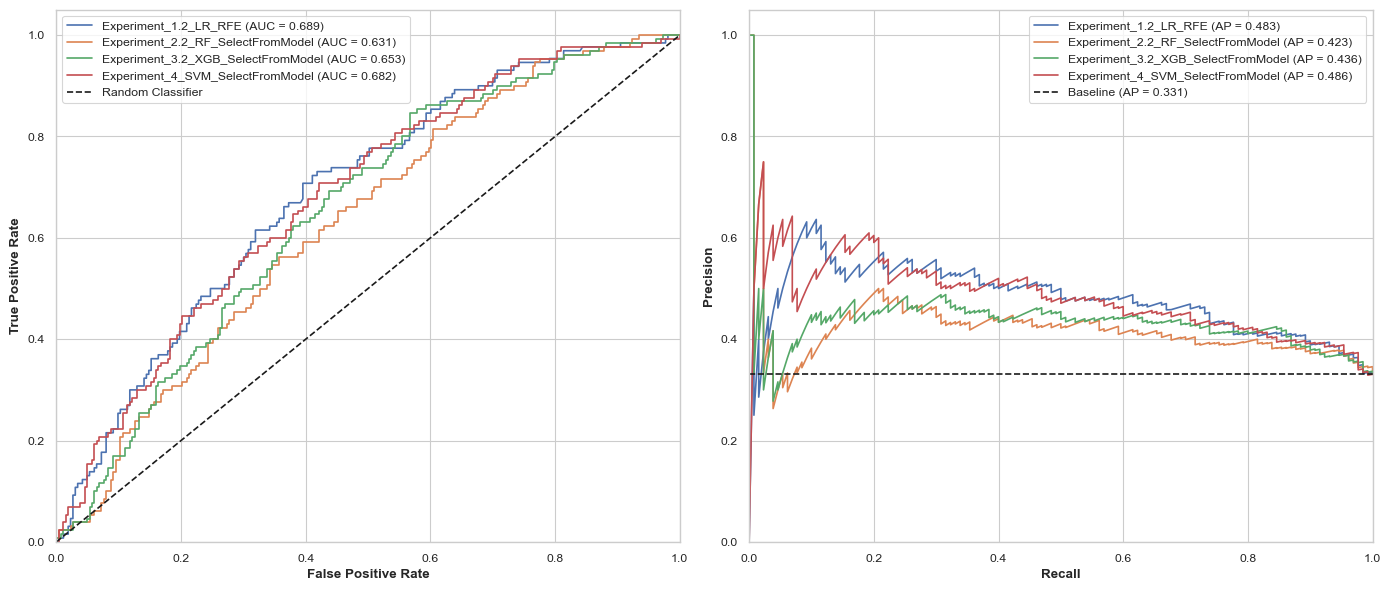

In [106]:
models_to_plot = [
    'Experiment_1.2_LR_RFE', 
    'Experiment_2.2_RF_SelectFromModel',
    'Experiment_3.2_XGB_SelectFromModel',
    'Experiment_4_SVM_SelectFromModel'

]

sns.set_theme(style = 'whitegrid', context='paper')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

first_model_data = models_to_plot[0]
pr_baseline =  np.sum(final_results[first_model_data]['y_true'])/len(final_results[first_model_data]['y_true'])

for i, model_name in enumerate(models_to_plot):

    metrics = final_results[model_name]



    #ROC curve
    ax1.plot(
        metrics['roc_fpr'], 
        metrics['roc_tpr'], 
        label=f"{model_name} (AUC = {metrics['roc_auc']:.3f})")
    
    #PR curve
    ax2.plot(
        metrics['recall'],
        metrics['precision'],
        label=f"{model_name} (AP = {metrics['ap_score']:.3f})")
    

ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.legend()

ax2.hlines(pr_baseline, 0, 1, colors='k', linestyles='--', label=f'Baseline (AP = {pr_baseline:.3f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()